In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.model_selection import train_test_split

In [2]:
class LinearRegression:
    
    def __init__(self, lr = 0.01, n_iters=1000):
          self.lr = lr
          self.n_iters = n_iters
          self.weights = None
          self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iters):
            y_pred = np.dot(X, self.weights) + self.bias

            dw = (1/n_samples) * np.dot(X.T, (y_pred - y)) # why is 2 not included as it is in the formula?
            db = (1/n_samples) * np.sum((y_pred - y))
    
            self.weights = self.weights - self.lr * dw
            self.bias = self.bias - self.lr * db

    def predict(self, X):
        y_pred = np.dot(X, self.weights) + self.bias
        return y_pred

In [3]:
X, y = datasets.make_regression(n_samples=100, n_features=1, noise=20, random_state=4)

In [6]:
X

(100, 1)

In [19]:
np.dot(X, reg.weights)[0]

np.float64(-101.13555602291237)

In [17]:
X[0]

array([-1.3474603])

In [18]:
reg.weights[0]

np.float64(75.05642755584665)

In [23]:
(X*reg.weights).shape

(100, 1)

In [22]:
(X.T *reg.weights).shape

(1, 100)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)

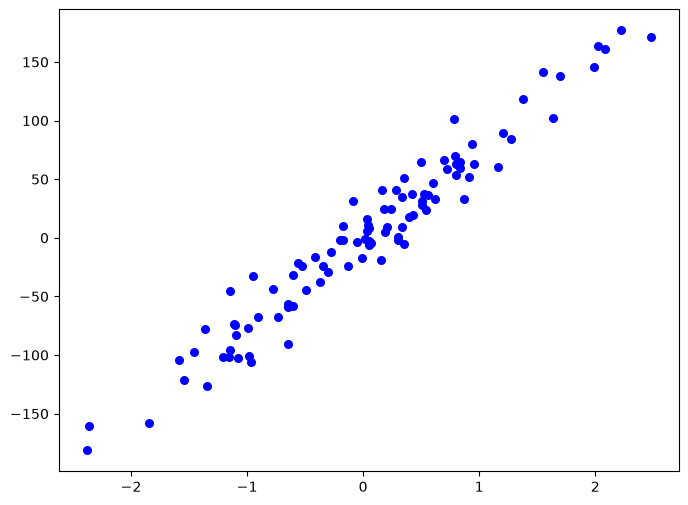

In [9]:
fig = plt.figure(figsize=(8,6))
plt.scatter(X[:, 0], y, color = 'b', marker ='o', s = 30)
plt.show()

In [10]:
reg = LinearRegression()
reg.fit(X_train, y_train)
predictions = reg.predict(X_test)

In [26]:
def mse(y_test, predictions):
    return np.mean((y_test - predictions)**2)

In [27]:
error = mse(y_test, predictions)
print(error)

783.8155465125492


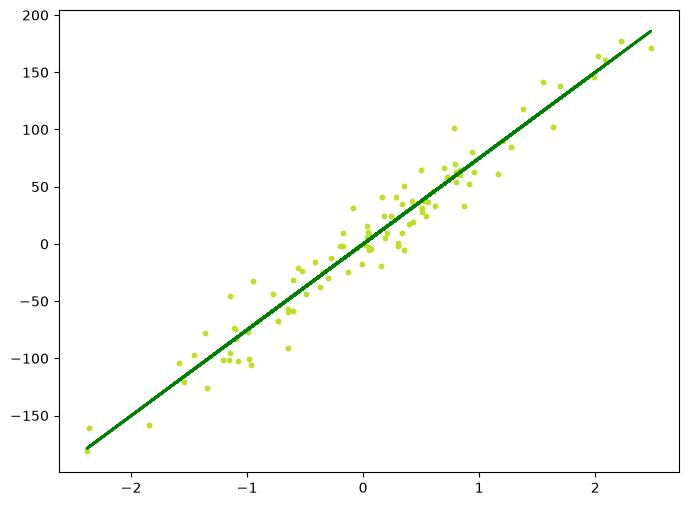

In [31]:
y_pred_line = reg.predict(X)
cmap = plt.get_cmap('viridis')
fig = plt.figure(figsize=(8,6))
m1 = plt.scatter(X_train, y_train, color=cmap(0.9), s=10)
m2 = plt.scatter(X_test, y_test, color=cmap(0.9), s=10)
plt.plot(X, y_pred_line, color='green', linewidth=2, label='Prediction')
plt.show()